# PRE-PROCESSING

In [44]:
import pandas as pd

# Importing the dataset
dataset = pd.read_csv('./data/merged/merged_final.csv')

def highlight_labels(val):
    color_map = {
        "polite": "green",
        "somewhat polite": "lightgreen",
        "neutral": "lightgray",
        "impolite": "red"
    }
    return f"background-color: {color_map.get(val, 'white')}; color: black"

dataset.head().style.applymap(highlight_labels, subset=['label'])

C:\Users\JoaoCoutinho\AppData\Local\Temp\ipykernel_16084\3700281982.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  dataset.head().style.applymap(highlight_labels, subset=['label'])


,text,label
0,Your flight has been rescheduled for 10:00 AM tomorrow. Please check the airport's website for any updates or changes.,neutral
1,We're happy to accommodate your dietary preferences. Our vegetarian options are carefully crafted to ensure a delicious and satisfying meal. Would you like me to recommend some dishes that fit your needs?,polite
2,"Our vegetarian options are available on the menu, and our chef can modify any dish to suit your dietary needs.",neutral
3,"I understand your frustration with the recent tournament results, and I'll review the standings to see what we can do to improve your experience.",somewhat polite
4,"I'll do my best to find a suitable replacement for the item you're looking for, but I need to know more about what you're looking for.",somewhat polite


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
#nltk.download('punkt') 
#nltk.download('wordnet')

corpus = []
lemmatizer = WordNetLemmatizer()

my_stop_words = set(stopwords.words('english'))
words_to_keep = {
    'no', 'couldn\'t', 'cry', 'not', 'can\'t', 'cannot', 'nor', 'except', 
    'nobody', 'but', 'serious', 'enough', 'nothing', 'alone', 'down', 'only', 
    'without', 'hereby', 'mustn\'t', 'shouldn\'t', 'never', 'neither', 'none', 
    'noone', 'nothing', 'isn\'t', 'wasn\'t', 'weren\'t', 'don\'t', 'doesn\'t', 
    'didn\'t', 'hasn\'t', 'haven\'t', 'hadn\'t', 'really', 'very', 'totally', 
    'absolutely', 'perhaps', 'maybe', 'kind', 'somewhat', 'please', 'thanks', 
    'thank', 'appreciate', 'excuse', 'sorry'
}

my_stop_words = my_stop_words - words_to_keep

for i in range(0, dataset['text'].size):
    # get review and remove non alpha chars
    review = re.sub('[^a-zA-Z]', ' ', dataset['text'][i])
    # to lower-case
    review = review.lower()
    word_list = nltk.word_tokenize(review)
    review = ' '.join([lemmatizer.lemmatize(w) for w in word_list if not w in my_stop_words])
    corpus.append(review)

print(corpus)

## VECTORIZATION

### BAG OF WORDS

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def bagofwords(data, ngram_range=(1, 1), max_features=20000):
    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)
    bow_features = vectorizer.fit_transform(data)

    return bow_features

### TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf(data, ngram_range=(1, 1), max_features=20000):
    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_features)
    tfidf_features = vectorizer.fit_transform(data)

    return tfidf_features

### WORD EMBEDDINGS

#### EMBEDDINGS MODELS

In [ ]:
import gensim.downloader
from scipy import stats
import numpy as np

#lens = [len(c.split()) for c in corpus]
#print(np.min(lens), np.max(lens), np.mean(lens), np.std(lens), stats.mode(lens))

trained_model = gensim.models.Word2Vec([sentence.split() for sentence in corpus], vector_size=100, window=3, min_count=2, workers=10, sg=1)
trained_model.wv.save("word2vec.model")

trained_model = gensim.models.KeyedVectors.load("word2vec.model")
#pretrained_model = gensim.downloader.load("glove-wiki-gigaword-50")

In [ ]:
import numpy as np
from scipy import stats

sequence_len = 40

def text_to_vector(embeddings, text, sequence_len):
    
    # split text into tokens
    tokens = text.split()
    
    # convert tokens to embedding vectors, up to sequence_len tokens
    vec = []
    n = 0
    i = 0
    while i < len(tokens) and n < sequence_len:   # while there are tokens and did not reach desired sequence length
        try:
            vec.extend(embeddings.get_vector(tokens[i]))
            n += 1
        except KeyError:
            True   # simply ignore out-of-vocabulary tokens
        finally:
            i += 1
    
    # add blanks up to sequence_len, if needed
    for j in range(sequence_len - n):
        vec.extend(np.zeros(embeddings.vector_size,))
    
    return vec

def text_to_mean_vector(embeddings, text):
    tokens = text.split()
    total_vector = []
    
    for token in tokens:
        try:
            total_vector.append(embeddings.get_vector(token))
        except KeyError:
            pass  # Ignore OOV words

    if len(total_vector) == 0:
        return np.zeros(embeddings.vector_size,)
        
    return np.mean(total_vector, axis=0)

def wordEmbeddingsVectorizer(data, model):
    vectors = []
    for doc in data:
        vectors.append(text_to_vector(model, doc, sequence_len))
    return np.array(vectors)
    
def wordEmbeddingsMeanVectorizer(data, model):
    vectors = []
    for doc in data:
        vectors.append(text_to_mean_vector(model, doc))
    return np.array(vectors)

### Lexicon

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def lexiconVader(data):
    analyzer = SentimentIntensityAnalyzer()
    features = []
    for text in data:
        sentiment_scores = analyzer.polarity_scores(text)
        features.append([sentiment_scores['neg'], sentiment_scores['neu'], sentiment_scores['pos'], sentiment_scores['compound']])
    return features
    

In [ ]:
from nrclex import NRCLex

def lexiconNRCLEX(data):
    lexicon_emotions = ['fear', 'anger', 'anticipation', 'trust', 'surprise', 'positive', 'negative', 'sadness', 'disgust', 'joy']
    features = []
    for text in data:
        text_emotion = NRCLex(text)
        features.append([text_emotion.affect_frequencies.get(emotion, 0) for emotion in lexicon_emotions])
    return features


### CHOOSING VECTORIZER

#### BOW

In [ ]:
features = bagofwords(corpus)
#features = bagofwords(corpus, ngram_range=(1,2))
#features = bagofwords(corpus, ngram_range=(2,2))
#features = bagofwords(corpus, ngram_range=(3,3))
labels = dataset['label']

#### TF-IDF

In [ ]:
#features = tfidf(corpus)
#features = tfidf(corpus, ngram_range=(1,2))
#features = tfidf(corpus, ngram_range=(2,2))
features = tfidf(corpus, ngram_range=(3,3))
labels = dataset['label']

#### EMBEDDINGS

In [ ]:
#features = wordEmbeddingsVectorizer(corpus, pretrained_model)
#features = wordEmbeddingsVectorizer(corpus, trained_model)
#features = wordEmbeddingsMeanVectorizer(corpus, pretrained_model)
features = wordEmbeddingsMeanVectorizer(corpus, trained_model)
labels = dataset['label']

#### LEXICON

In [ ]:
features = lexiconNRCLEX(corpus)
#features = lexiconVader(corpus)
labels = dataset['label']

## MODEL TRAINING

In [ ]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.20, random_state=42)

c:\Users\JoaoCoutinho\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### NAIVE BAYES

In [ ]:
from sklearn.naive_bayes import MultinomialNB

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-6, 1e-1, log=True)
    fit_prior = trial.suggest_categorical('fit_prior', [True, False])
    force_alpha = trial.suggest_categorical('force_alpha', [True, False])

    model = MultinomialNB(alpha=alpha, fit_prior=fit_prior, force_alpha=force_alpha)

    return cross_val_score(model, X_train, y_train, cv=10).mean()

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)

clf = MultinomialNB(alpha=0.06639888974640262, fit_prior=True, force_alpha=False)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8126746506986028
                 precision    recall  f1-score   support

       impolite       0.96      0.98      0.97      4937
        neutral       0.85      0.74      0.79      4988
         polite       0.83      0.71      0.76      5046
somewhat polite       0.66      0.83      0.73      5069

       accuracy                           0.81     20040
      macro avg       0.83      0.81      0.81     20040
   weighted avg       0.82      0.81      0.81     20040

[[4819   40   18   60]
 [  99 3704  292  893]
 [  28  208 3575 1235]
 [  58  405  418 4188]]


#### LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression

def objective(trial):
    C = trial.suggest_loguniform('C', 0.01, 10)
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga'])

    if solver in ['lbfgs', 'sag', 'newton-cg']:
        penalty = 'l2'
    else:
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    model = LogisticRegression(max_iter=500, C=C, penalty=penalty, solver=solver, random_state=42)
    
    return cross_val_score(model, X_train, y_train, cv=10).mean()

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)

clf = LogisticRegression(C=0.5017852744800145, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.48512974051896207
                 precision    recall  f1-score   support

       impolite       0.54      0.58      0.56      4937
        neutral       0.42      0.34      0.38      4988
         polite       0.54      0.66      0.59      5046
somewhat polite       0.40      0.36      0.38      5069

       accuracy                           0.49     20040
      macro avg       0.48      0.49      0.48     20040
   weighted avg       0.48      0.49      0.48     20040

[[2868  832  719  518]
 [1038 1702  778 1470]
 [ 497  477 3315  757]
 [ 919 1008 1305 1837]]


#### DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy'])
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        criterion=criterion,
        max_features=max_features,
        random_state=42
    )

    return cross_val_score(model, X_train, y_train, cv=10).mean()

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)


clf = DecisionTreeClassifier(max_depth=38, min_samples_split=5, min_samples_leaf=1, criterion='gini', max_features=None)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.5527445109780439
                 precision    recall  f1-score   support

       impolite       0.62      0.64      0.63      4937
        neutral       0.48      0.60      0.53      4988
         polite       0.63      0.64      0.63      5046
somewhat polite       0.48      0.34      0.40      5069

       accuracy                           0.55     20040
      macro avg       0.55      0.55      0.55     20040
   weighted avg       0.55      0.55      0.55     20040

[[3140 1043  306  448]
 [ 796 2985  488  719]
 [ 409  674 3214  749]
 [ 717 1516 1098 1738]]


#### RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_float('min_samples_split', 0.01, 1.0, log=True)
    min_samples_leaf = trial.suggest_float('min_samples_leaf', 0.01, 0.5, log=True)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False]) 
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        random_state=42
    )

    return cross_val_score(model, X_train, y_train, cv=10).mean()

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)

clf = RandomForestClassifier(n_estimators=272, max_depth=9, min_samples_split=0.15347844329500454, min_samples_leaf=0.010174666947265116, max_features='sqrt', bootstrap=False)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.5209081836327345
                 precision    recall  f1-score   support

       impolite       0.52      0.65      0.58      4937
        neutral       0.47      0.44      0.45      4988
         polite       0.60      0.70      0.65      5046
somewhat polite       0.47      0.30      0.36      5069

       accuracy                           0.52     20040
      macro avg       0.51      0.52      0.51     20040
   weighted avg       0.51      0.52      0.51     20040

[[3220  958  439  320]
 [1238 2200  605  945]
 [ 628  438 3512  468]
 [1146 1130 1286 1507]]


#### SUPPORT VECTOR MACHINE (SVM)

In [ ]:
from sklearn.svm import SVC
from tqdm import tqdm

def objective(trial):
    C = trial.suggest_float('C', 0.1, 10.0, log=True)
    kernel = trial.suggest_categorical('kernel', ['linear', 'poly', 'rbf', 'sigmoid'])
    degree = trial.suggest_int('degree', 2, 5) if kernel == 'poly' else 3
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    tol = trial.suggest_float('tol', 1e-5, 1e-1, log=True)
    
    model = SVC(C=C, kernel=kernel, degree=degree, gamma=gamma, tol=tol, random_state=42)

    return cross_val_score(model, X_train, y_train, cv=10).mean()

# Create study
#study = optuna.create_study(direction='maximize')

# Use tqdm directly to show progress
#for _ in tqdm(range(15)):
#    study.optimize(objective, n_trials=1)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)


clf = SVC(C=0.9314990880349366, kernel='linear', gamma='auto', tol=0.010380902120776503)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

#### NEURAL NETWORK (MLP)

In [ ]:
from sklearn.neural_network import MLPClassifier

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-1, 1e-1, log=True)
    hidden_layer_sizes = trial.suggest_int('hidden_layer_sizes', 1, 100)
    activation = trial.suggest_categorical('activation', ['identity', 'logistic', 'tanh', 'relu'])
    solver = trial.suggest_categorical('solver', ['lbfgs', 'sgd', 'adam'])
    learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)
    
    model = MLPClassifier(
        alpha=alpha,
        hidden_layer_sizes=(hidden_layer_sizes,),
        activation=activation,
        solver=solver,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        random_state=42
    )

    return cross_val_score(model, X_train, y_train, cv=10).mean()

#study = optuna.create_study(direction='maximize')
#study.optimize(objective, n_trials=50)

#print("Best hyperparameters:", study.best_params)
#print("Best score:", study.best_value)

clf = MLPClassifier(alpha=0.1, hidden_layer_sizes=87, activation='tanh', solver='lbfgs', learning_rate_init=0.0605673176440167, max_iter=692)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
y_pred_mlp = y_pred.copy() 

c:\Users\JoaoCoutinho\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


0.8097804391217565
                 precision    recall  f1-score   support

       impolite       0.84      0.97      0.90      4937
        neutral       0.83      0.76      0.79      4988
         polite       0.80      0.77      0.79      5046
somewhat polite       0.76      0.75      0.75      5069

       accuracy                           0.81     20040
      macro avg       0.81      0.81      0.81     20040
   weighted avg       0.81      0.81      0.81     20040

[[4766   82   33   56]
 [ 419 3787  287  495]
 [ 288  222 3896  640]
 [ 184  481  625 3779]]


## CAUSE OF ERRORS

In [ ]:
emotions_to_int = {
    'polite': 0,
    'somewhat polite': 1,
    'neutral': 2,
    'impolite': 3
}

int_to_emotions = {v: k for k, v in emotions_to_int.items()}

prediction = y_pred_mlp
wrong_predictions = y_test[y_test != prediction].index
for index in wrong_predictions:
    print(corpus[index])
    print(labels[index])
    print('Real: ', labels[index])
    print('Pred:', prediction[y_test.index.get_loc(index)])
    print('\n')

not sure system showing available loan option but likely due technical glitch look get back accurate answer
neutral
Real:  neutral
Pred: somewhat polite


sorry hear trouble online course material but seems already completed required hour receive certificate let check status
somewhat polite
Real:  somewhat polite
Pred: neutral


sorry hear dolphin show canceled due summer heatwave offering complimentary upgrade vip animal encounter experience gesture goodwill
polite
Real:  polite
Pred: somewhat polite


happy help question international menu option assist today
somewhat polite
Real:  somewhat polite
Pred: polite


happy help improve graphic design skill but need let know course fee non refundable first week however experiencing financial difficulty offer payment plan option might suitable
polite
Real:  polite
Pred: somewhat polite


happy help street food order but please note transaction subject service charge peak summer month like make change cancellation happy assist
polite
Real:  

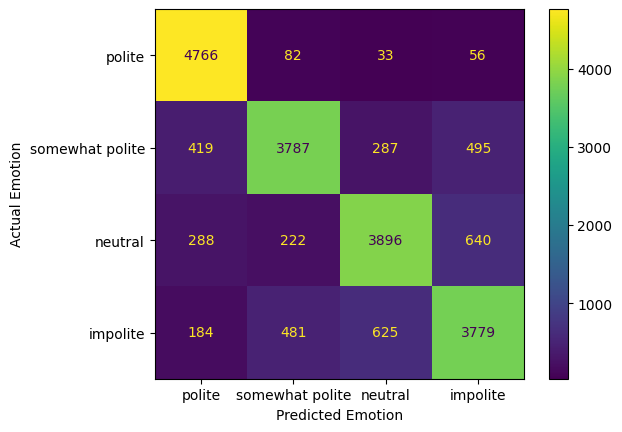

In [43]:
from matplotlib import pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, prediction))

cm_display.plot()
plt.xticks(list(emotions_to_int.values()), list(emotions_to_int.keys()))
plt.yticks(list(emotions_to_int.values()), list(emotions_to_int.keys()))
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.show()

#### USER INPUT

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction import text

import re
import nltk
from nltk.corpus import stopwords
#from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
#nltk.download('punkt') 
#nltk.download('wordnet')
#from sklearn.feature_extraction import text

sentence = input("Enter some text:")

corpus = []
#ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

my_stop_words = set(stopwords.words('english'))
words_to_keep = {
    'no', 'couldn\'t', 'cry', 'not', 'can\'t', 'cannot', 'nor', 'except', 
    'nobody', 'but', 'serious', 'enough', 'nothing', 'alone', 'down', 'only', 
    'without', 'hereby', 'mustn\'t', 'shouldn\'t', 'never', 'neither', 'none', 
    'noone', 'nothing', 'isn\'t', 'wasn\'t', 'weren\'t', 'don\'t', 'doesn\'t', 
    'didn\'t', 'hasn\'t', 'haven\'t', 'hadn\'t', 'really', 'very', 'totally', 
    'absolutely', 'perhaps', 'maybe', 'kind', 'somewhat', 'please', 'thanks', 
    'thank', 'appreciate', 'excuse', 'sorry'
}

my_stop_words = my_stop_words - words_to_keep

review = re.sub('[^a-zA-Z]', ' ', sentence)
# to lower-case
review = review.lower()
# split into tokens, apply stemming
#review = ' '.join([ps.stem(w) for w in review.split()])
word_list = nltk.word_tokenize(review)
review = ' '.join([lemmatizer.lemmatize(w) for w in word_list if not w in my_stop_words])

features = tfidf([review], ngram_range=(3,3))

prediction = clf.predict(features)
print(prediction)
print(f"Prediction: {prediction[0]}")